In [1]:
from eib import *
sns.set_context("paper")

/tmp/ipykernel_5036/4016983545.py:43: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  eib = xr.open_dataset("../extended-ibtracs/extended-ibtracs_"+b+".nc")


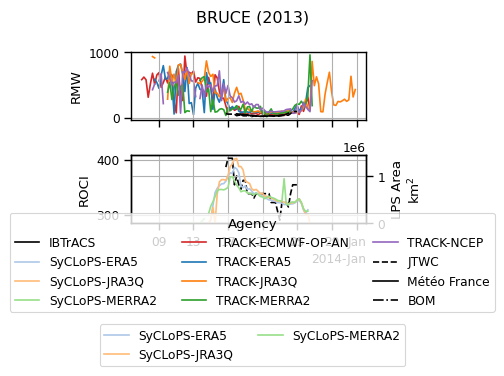

In [4]:
def plot_size(TRACK):
    fig, axs = plt.subplots(2, sharex = True, figsize = cm2inch([10,7]),)

    # RMW
    for s in TRACK.source.values:
        TRACK.sel(source = s).radius_max_wind.plot(ax = axs[0], color = PALETTE[s], label = s, zorder = -1)
    TRACK.usa_rmw.plot(ax = axs[0], color = "k", linestyle = "--", label = "JTWC")
    TRACK.reunion_rmw.plot(ax = axs[0], color = "k", label = "Météo France")
    TRACK.bom_rmw.plot(ax = axs[0], color = "k", linestyle = "-.", label = "BOM")
    axs[0].set_ylabel("RMW")

    # ROCI
    TRACK.usa_roci.plot(ax = axs[1], color = "k", linestyle = "--")
    axs[1].set_ylabel("ROCI")

    # Size
    twinax = axs[1].twinx()
    for s in TRACK.source.values[TRACK.lpsarea.notnull().sum("time") > 1]:
        TRACK.sel(source = s).lpsarea.plot(ax = twinax, color = PALETTE[s], label = s)
    twinax.set_ylabel("LPS Area\nkm$^{2}$")
    twinax.set_ylim(0)
    #twinax.legend()
    
    for ax in np.concat([axs, [twinax]]):
        ax.set_xlabel("")
        ax.set_title("")
        ax.grid()
        
    #axs[-1].xaxis.set_major_formatter(DateFormatter('%d/%m'))
    #axs[-1].set_xlabel("Sept. 2020", loc = "right")
    
    NAME = TRACK.name.values[0]
    SEASON = TRACK.time.dt.year.values[0]
    fig.suptitle(NAME + ' ('+str(SEASON)+')')
    plt.tight_layout()

    fig.legend(*axs[0].get_legend_handles_labels(), title = "Agency",
               loc = "outside lower center", ncol = 3, bbox_to_anchor = (0.5,-0.14))
    fig.legend(*twinax.get_legend_handles_labels(), title = "",
               loc = "outside upper center", ncol = 2, bbox_to_anchor = (0.5,-0.14))

b = "SI"
eib = xr.open_dataset("../extended-ibtracs/extended-ibtracs_"+b+".nc")
NAME, SEASON = "BRUCE", 2013
TRACK = eib.where((eib.name == NAME) & (eib.time.dt.year == SEASON), drop = True)
TRACK = TRACK.set_coords("time").swap_dims({"record":"time"})
plot_size(TRACK)

plt.savefig("size_info.png", bbox_inches = "tight")

In [7]:
TRACK.radius_max_wind

<xarray.DataArray 'radius_max_wind' (source: 9, time: 100)> Size: 7kB
array([[         nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
...
        696.13422551, 757.58615555, 661.18219038, 563.43120921,
        561.82821185, 324.54143524,          nan, 295.32015332,
        502.31768149, 309.03780993, 500.61897206, 464.58567808,
        504.57940224, 402.56646421, 486.10973929, 492.5339238 ,
        717.63125946, 262.45215146, 523.66662537, 373.56105522,
        493.76921952, 333.14963725, 307.68471256, 241.28598176,
        260.24730605, 336.75151249, 235.82864444, 251.9637257 ,
        207.45131812, 241.00084489, 201.7316571 , 213.64779589,
        154.67625475, 203.03111776, 201.50491862, 117.01741953,
        147.59594445, 111.64993385,  82.7288936 ,  87.44710387,
        102.38815959,  89.91067862,  91.81315852,  95.4519252 ,
         98.28965649,  96.81730408, 106.81793493, 126.19309474,
        130.93974984, 135.94007841,  68.91543232,  69.72579721,
        181.57463302,  79.38152442, 114.12340641, 237.17435368,
        175.73409904, 127.47885152,  94.04211986, 568.6791945 ,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan]])
Coordinates:
  * time     (time) datetime64[ns] 800B 2013-12-07 ... 2013-12-31T18:00:00
  * source   (source) <U17 612B 'IBTrACS' 'SyCLoPS-ERA5' ... 'TRACK-NCEP'
    record   (time) int64 800B 157060 157061 157062 ... 157157 157158 157159
Attributes:
    units:    km

In [37]:
list(TRACK.variables.keys())

['lon',
 'lat',
 'pres',
 'wind10',
 'vo850',
 'label',
 'is_tc',
 'lpsarea',
 'track_id',
 'name',
 'time',
 'season',
 'number',
 'basin',
 'subbasin',
 'nature',
 'wmo_wind',
 'wmo_pres',
 'wmo_agency',
 'track_type',
 'dist2land',
 'landfall',
 'iflag',
 'usa_agency',
 'usa_atcf_id',
 'usa_lat',
 'usa_lon',
 'usa_status',
 'usa_wind',
 'usa_pres',
 'usa_sshs',
 'usa_r34_ne',
 'usa_r34_se',
 'usa_r34_sw',
 'usa_r34_nw',
 'usa_r50_ne',
 'usa_r50_se',
 'usa_r50_sw',
 'usa_r50_nw',
 'usa_r64_ne',
 'usa_r64_se',
 'usa_r64_sw',
 'usa_r64_nw',
 'usa_poci',
 'usa_roci',
 'usa_rmw',
 'usa_eye',
 'reunion_lat',
 'reunion_lon',
 'reunion_type',
 'reunion_wind',
 'reunion_pres',
 'reunion_tnum',
 'reunion_ci',
 'reunion_rmw',
 'reunion_r34_ne',
 'reunion_r34_se',
 'reunion_r34_sw',
 'reunion_r34_nw',
 'reunion_r50_ne',
 'reunion_r50_se',
 'reunion_r50_sw',
 'reunion_r50_nw',
 'bom_lat',
 'bom_lon',
 'bom_type',
 'bom_wind',
 'bom_pres',
 'bom_tnum',
 'bom_ci',
 'bom_rmw',
 'bom_r34_ne',
 'bom_

In [31]:
b = "SI"
eib = xr.open_dataset("../extended-ibtracs/extended-ibtracs_"+b+".nc")

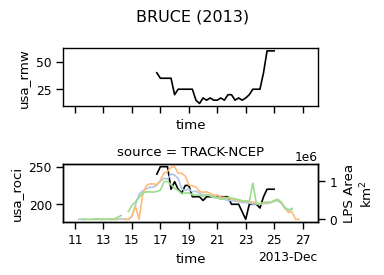

In [35]:
NAME, SEASON = "BRUCE", 2013
TRACK = eib.where((eib.name == NAME) & (eib.time.dt.year == SEASON), drop = True)
TRACK = TRACK.set_coords("time").swap_dims({"record":"time"})
plot_size(TRACK)

In [32]:
tids = np.unique(clean(eib.where((eib.usa_sshs >= 5) & 
                                 (eib.time.dt.year >= 1980) &
                                eib.usa_rmw.notnull() & 
                                 eib.usa_roci.notnull()
                                )).track_id.values)
len(tids)

18

100%|██████████| 18/18 [00:23<00:00,  1.32s/it]


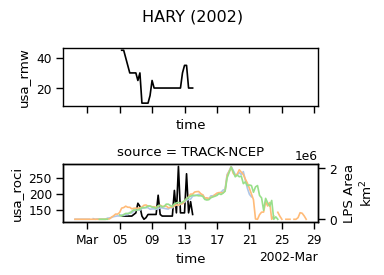

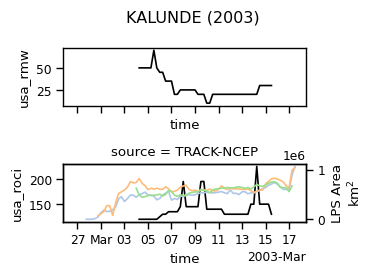

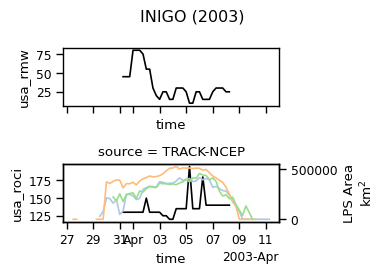

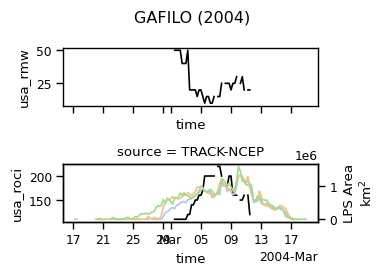

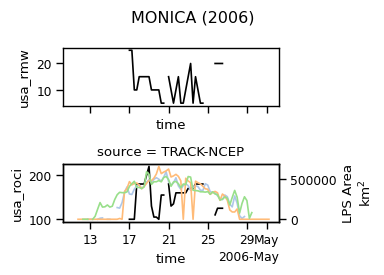

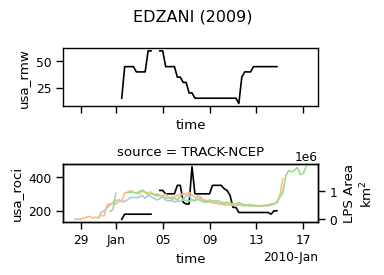

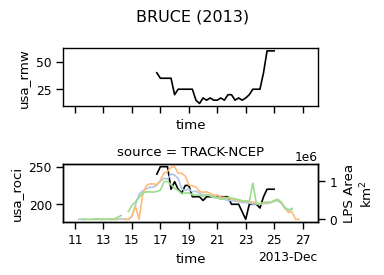

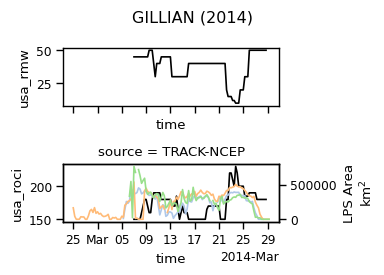

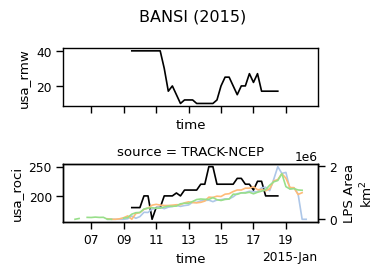

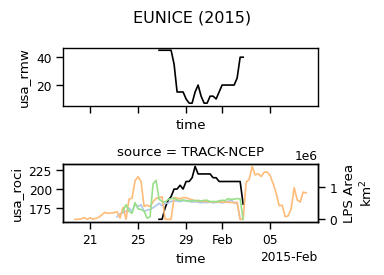

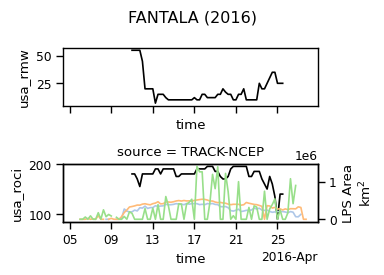

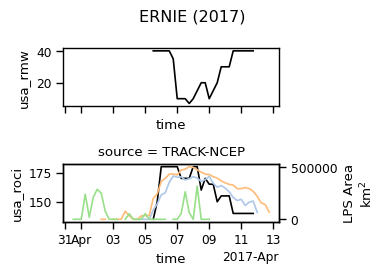

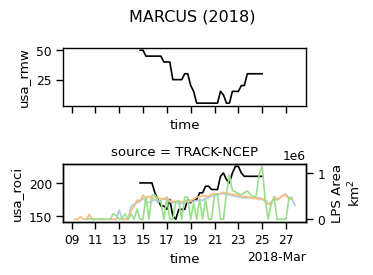

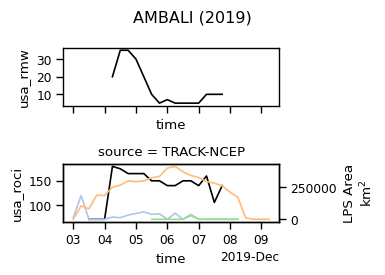

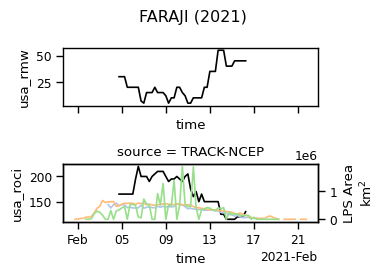

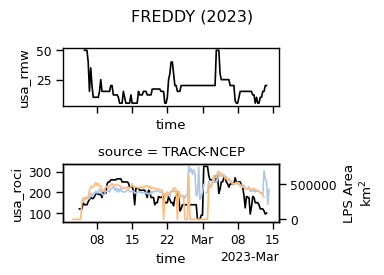

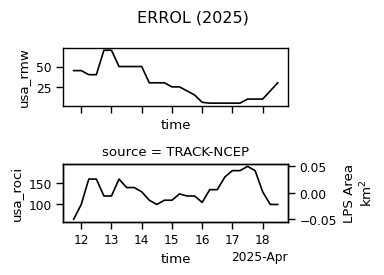

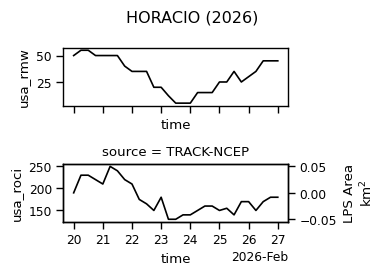

In [34]:
for tid in tqdm(tids):
    TRACK = clean(eib.where((eib.track_id == tid),))
    TRACK = TRACK.set_coords("time").swap_dims({"record":"time"})
    plot_size(TRACK)

In [30]:
TRACK

<xarray.Dataset> Size: 192kB
Dimensions:                 (source: 9, time: 97)
Coordinates:
  * time                    (time) datetime64[ns] 776B 2004-08-13T06:00:00 .....
  * source                  (source) <U17 612B 'IBTrACS' ... 'TRACK-NCEP'
    record                  (time) int64 776B 193917 193918 ... 194012 194013
Data variables: (12/124)
    lon                     (source, time) float32 3kB nan nan nan ... 165.0 nan
    lat                     (source, time) float32 3kB nan nan nan ... 54.12 nan
    pres                    (source, time) float32 3kB nan nan ... 1.006e+03 nan
    wind10                  (source, time) float32 3kB nan nan nan ... 12.37 nan
    vo850                   (source, time) float32 3kB nan nan nan ... 5.605 nan
    label                   (source, time) object 7kB b'' b'' b'' ... b'' b''
    ...                      ...
    b_roll                  (source, time) float32 3kB nan nan nan ... nan nan
    WCSI                    (source, time) float64 7kB 0.0 0.0 0.0 ... 0.0 0.0
    WCS                     (source, time) float64 7kB 0.0 0.0 0.0 ... 0.0 0.0
    CCA                     (source, time) float64 7kB 0.0 0.0 0.0 ... 0.0 0.0
    is_etc                  (source, time) float64 7kB 0.0 0.0 0.0 ... 0.0 0.0
    ET                      (source, time) float32 3kB 0.0 0.0 0.0 ... 0.0 0.0